In [91]:
%pip install hmmlearn
%pip install cvxpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Data ingestion

import yfinance as yf
import numpy as np
import pandas as pd
import os
os.environ['FRED_API_KEY'] = 'YOUR_FRED_API_KEY'

# --- Locked-in universe ---
UNIVERSE = ['SPY', 'TLT', 'IEF', 'GLD', 'HYG']




# 1. Fetch asset prices
raw = yf.download(UNIVERSE, start='2005-01-01', auto_adjust=True, progress=False)
prices = raw['Close']

# 2. Fetch VIX (feature only, not traded)
vix_raw = yf.download('^VIX', start='2005-01-01', auto_adjust=True, progress=False)
vix = vix_raw['Close']
vix.columns = ['VIX']

# 3. Convert prices to returns, merge with VIX
returns = prices.pct_change()
returns.columns = [f"{col}_ret" for col in returns.columns]
dataset = returns.join(vix, how='left')

dataset["SPY_ret"] = returns["SPY_ret"]
dataset["TLT_ret"] = returns["TLT_ret"]
dataset["HYG_ret"] = returns["HYG_ret"]
dataset["GLD_ret"] = returns["GLD_ret"]
dataset["VIX"] = vix

# 4. Clean
dataset = dataset.sort_index()
dataset = dataset[~dataset.index.duplicated(keep='first')]
dataset = dataset.dropna(subset=[c for c in dataset.columns if c.endswith('_ret')], how='all')
dataset = dataset.ffill(limit=2)
dataset = dataset.replace([np.inf, -np.inf], np.nan)
dataset = dataset.dropna()

print(dataset.shape)
print(dataset.isna().sum())
dataset.head()




(4848, 6)
GLD_ret    0
HYG_ret    0
IEF_ret    0
SPY_ret    0
TLT_ret    0
VIX        0
dtype: int64


,GLD_ret,HYG_ret,IEF_ret,SPY_ret,TLT_ret,VIX
Date,,,,,,
2007-04-12,-0.001342,0.000672,0.000971,0.004444,0.000228,12.71
2007-04-13,0.012688,-0.001820,-0.001697,0.004563,-0.003089,12.20
2007-04-16,0.008255,-0.000384,0.001093,0.009496,0.005509,11.98
2007-04-17,-0.005848,-0.000480,0.004246,0.002659,0.005593,12.14
2007-04-18,0.005588,0.000287,0.002296,0.001223,0.004995,12.42


In [95]:
print(dataset.shape)
dataset.describe()

(4848, 6)


,GLD_ret,HYG_ret,IEF_ret,SPY_ret,TLT_ret,VIX
count,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000
mean,0.000416,0.000215,0.000136,0.000489,0.000160,19.893131
std,0.011406,0.006851,0.004387,0.012410,0.009537,8.723569
min,-0.102742,-0.080975,-0.025073,-0.109423,-0.066683,9.140000
25%,-0.005139,-0.001885,-0.002498,-0.004105,-0.005618,14.180000
50%,0.000538,0.000316,0.000216,0.000705,0.000451,17.580000
75%,0.006221,0.002461,0.002679,0.005988,0.005737,22.812500
max,0.112905,0.122690,0.034262,0.145199,0.075196,82.690002


In [ ]:
# regime detection

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# Use YoY inflation rate, not the raw trending CPI index level
# dataset['CPI_yoy'] = dataset['CPIAUCSL'].pct_change(252) * 100  # ~252 trading days/year

feature_cols = [
    "SPY_ret",      # US Equities
    "TLT_ret",      # Long-term Treasuries
    "GLD_ret",      # Gold
    "HYG_ret",      # High Yield Corporate Bonds
    "VIX"      # CBOE Volatility Index
]


dataset = dataset.dropna(subset=feature_cols)
hmm_features = dataset[feature_cols].copy()

scaler = StandardScaler()
X = scaler.fit_transform(hmm_features)

model = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
model.fit(X)

print("Converged:", model.monitor_.converged)
hidden_states = model.predict(X)
dataset['regime'] = hidden_states
dataset['regime'].value_counts()

Converged: True


regime
0    2376
1    1930
2     542
Name: count, dtype: int64

In [97]:
hmm_features.isna().sum()

SPY_ret    0
TLT_ret    0
GLD_ret    0
HYG_ret    0
VIX        0
dtype: int64

In [ ]:
# Rank states by average SPY return: lowest return = worst regime, highest = best
regime_stats = dataset.groupby('regime')['SPY_ret'].mean().sort_values()
regime_labels = {
    regime_stats.index[0]: 'Crisis',
    regime_stats.index[1]: 'Bear',
    regime_stats.index[2]: 'Bull',
}
print(regime_labels)
dataset['regime_label'] = dataset['regime'].map(regime_labels)




{np.int64(2): 'Crisis', np.int64(1): 'Bear', np.int64(0): 'Bull'}


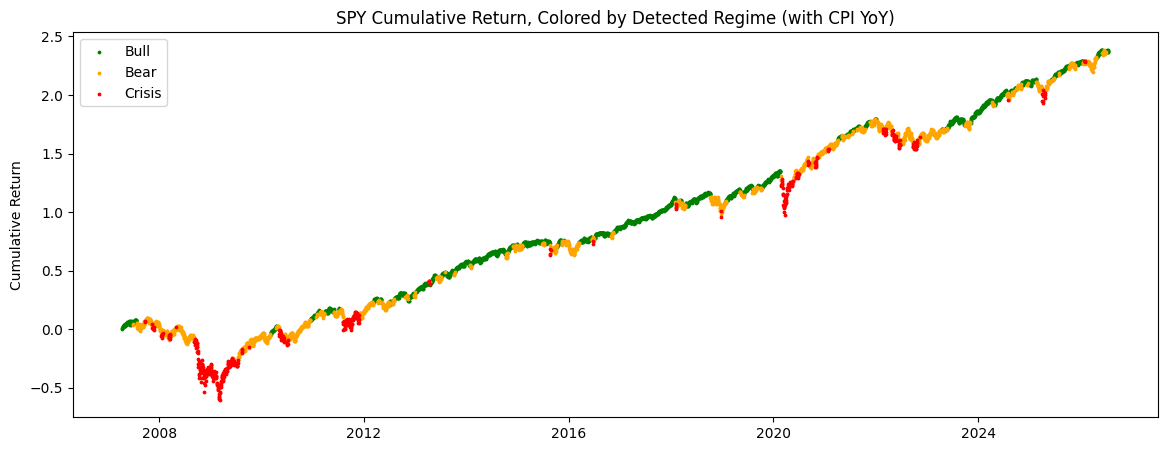

In [99]:
import matplotlib.pyplot as plt

# Compute ONE continuous cumulative return series across all days
cum_return = dataset['SPY_ret'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Bull': 'green', 'Bear': 'orange', 'Crisis': 'red'}

for label, color in colors.items():
    mask = dataset['regime_label'] == label
    ax.scatter(dataset.index[mask], cum_return[mask], s=3, color=color, label=label)

ax.set_title('SPY Cumulative Return, Colored by Detected Regime (with CPI YoY)')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.show()

In [100]:
print(model.transmat_)
dataset['regime_label'].ne(dataset['regime_label'].shift()).cumsum().value_counts().describe()

[[9.73160698e-01 2.61953872e-02 6.43914717e-04]
 [3.29078374e-02 9.48633123e-01 1.84590399e-02]
 [2.40428374e-05 6.78580537e-02 9.32117903e-01]]


count    176.000000
mean      27.545455
std       37.035399
min        1.000000
25%        6.000000
50%       15.500000
75%       31.000000
max      304.000000
Name: count, dtype: float64

In [101]:
import numpy as np
import pandas as pd

return_cols = ['SPY_ret', 'TLT_ret', 'IEF_ret', 'GLD_ret', 'HYG_ret']
asset_names = return_cols

def widen_regime_mask(labels, target_label, window=0):
    original_index = labels.index  # bugfix: use the caller's own index, not the
                                    # global `dataset` -- this broke when called
                                    # with a train_data slice shorter than dataset
    labels = labels.reset_index(drop=True)
    exact_mask = (labels == target_label).values
    widened_mask = exact_mask.copy()
    idx = np.where(exact_mask)[0]
    for i in idx:
        lo = max(0, i - window)
        hi = min(len(labels), i + window + 1)
        widened_mask[lo:hi] = True
    return pd.Series(widened_mask, index=original_index)

window = 0
mask_bull = widen_regime_mask(dataset['regime_label'], 'Bull', window)
mask_bear = widen_regime_mask(dataset['regime_label'], 'Bear', window)
mask_crisis = widen_regime_mask(dataset['regime_label'], 'Crisis', window)

mu_bull = dataset.loc[mask_bull, return_cols].mean() * 252
mu_bear = dataset.loc[mask_bear, return_cols].mean() * 252
mu_crisis = dataset.loc[mask_crisis, return_cols].mean() * 252

Sigma = dataset[return_cols].cov() * 252

print(mu_bull)

SPY_ret    0.255478
TLT_ret    0.024915
IEF_ret    0.015225
GLD_ret    0.056626
HYG_ret    0.073906
dtype: float64


In [ ]:

#optimization

import cvxpy as cp
import numpy as np

#MIN VOLATILITY

def min_volatility(Sigma, asset_names, w_prev=None, lambda_turnover=0.0):
    """
    w_prev: pd.Series of current/previous weights (same index as asset_names).
            If provided along with lambda_turnover > 0, an L1 turnover penalty
            is added to the objective: lambda_turnover * ||w - w_prev||_1
            (L1 norm of the weight change = 2x one-way turnover).
    """
    n = len(asset_names)
    w = cp.Variable(n)

    portfolio_variance = cp.quad_form(w, Sigma.values)
    objective = portfolio_variance

    if w_prev is not None and lambda_turnover > 0:
        w_prev_arr = w_prev.reindex(asset_names).values if hasattr(w_prev, 'reindex') else np.asarray(w_prev)
        objective = objective + lambda_turnover * cp.norm1(w - w_prev_arr)

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
    ]

    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve()

    return pd.Series(w.value, index=asset_names)

asset_names = return_cols  # ['SPY_ret', 'TLT_ret', 'IEF_ret', 'GLD_ret', 'HYG_ret']

weights_crisis = min_volatility(Sigma, asset_names)
print(weights_crisis)
print("Sum of weights:", weights_crisis.sum())


SPY_ret    7.335665e-02
TLT_ret   -2.796317e-21
IEF_ret    7.009560e-01
GLD_ret    2.147090e-02
HYG_ret    2.042164e-01
dtype: float64
Sum of weights: 1.0


In [103]:
#MAX SHARPE RATIO

def max_sharpe(mu, Sigma, asset_names, risk_free_rate=0.03, min_spy_weight=0.0,
               w_prev=None, lambda_turnover=0.0):
    """
    w_prev / lambda_turnover: same idea as min_volatility, but max_sharpe is solved
    in the transformed (y, kappa) space where w = y / kappa. Penalizing
    ||y - kappa*w_prev||_1 stays convex and is equivalent to penalizing
    kappa * ||w - w_prev||_1 -- i.e. turnover scaled by the (endogenous) leverage
    variable kappa, not exact unscaled turnover. Treat lambda_turnover here as a
    knob to retune rather than a value directly comparable to the one used in
    min_volatility.
    """
    n = len(asset_names)
    y = cp.Variable(n)
    kappa = cp.Variable(nonneg=True)
    portfolio_variance = cp.quad_form(y, Sigma.values)
    objective = portfolio_variance

    if w_prev is not None and lambda_turnover > 0:
        w_prev_arr = w_prev.reindex(asset_names).values if hasattr(w_prev, 'reindex') else np.asarray(w_prev)
        objective = objective + lambda_turnover * cp.norm1(y - kappa * w_prev_arr)

    constraints = [
        (mu.values - risk_free_rate) @ y == 1,
        cp.sum(y) == kappa,
        y >= 0,
    ]

    spy_idx = asset_names.index('SPY_ret')
    if min_spy_weight > 0:
        constraints.append(y[spy_idx] >= min_spy_weight * kappa)

    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve()

    w = y.value / kappa.value
    return pd.Series(w, index=asset_names)

weights_bull = max_sharpe(mu_bull, Sigma, asset_names)
print(weights_bull)
print("Sum of weights:", weights_bull.sum())


SPY_ret    7.264430e-01
TLT_ret    2.652936e-01
IEF_ret    5.302231e-22
GLD_ret    8.263381e-03
HYG_ret    1.352644e-21
dtype: float64
Sum of weights: 1.0


In [104]:
def max_return_with_risk_cap(mu, Sigma, asset_names, target_vol=0.08):
    n = len(asset_names)
    w = cp.Variable(n)
    target_variance = target_vol ** 2

    constraints = [
        cp.quad_form(w, Sigma.values) <= target_variance,
        cp.sum(w) == 1,
        w >= 0,
    ]

    problem = cp.Problem(cp.Maximize(mu.values @ w), constraints)
    problem.solve()

    if w.value is None:
        return min_volatility(Sigma, asset_names)

    return pd.Series(w.value, index=asset_names)

In [105]:
def get_portfolio_weights(regime_label, mu_bull, mu_bear, mu_crisis, Sigma, asset_names, risk_free_rate=0.03):
    """
    Dynamic Constraint Mapping: routes to the correct convex optimization
    objective depending on the detected regime.

    Bull   -> Maximum Sharpe (growth-seeking)
    Bear   -> Minimum Volatility (defensive, same as Crisis for now)
    Crisis -> Minimum Volatility (capital preservation)
    """
    if regime_label == 'Bull':
        return max_sharpe(mu_bull, Sigma, asset_names, risk_free_rate)
    elif regime_label in ('Bear', 'Crisis'):
        return min_volatility(Sigma, asset_names)
    else:
        raise ValueError(f"Unknown regime label: {regime_label}")
    


for regime in ['Bull', 'Bear', 'Crisis']:
    w = get_portfolio_weights(regime, mu_bull, mu_bear, mu_crisis, Sigma, asset_names)
    print(f"--- {regime} ---")
    print(w.round(4))
    print()

--- Bull ---
SPY_ret    0.7264
TLT_ret    0.2653
IEF_ret    0.0000
GLD_ret    0.0083
HYG_ret    0.0000
dtype: float64

--- Bear ---
SPY_ret    0.0734
TLT_ret   -0.0000
IEF_ret    0.7010
GLD_ret    0.0215
HYG_ret    0.2042
dtype: float64

--- Crisis ---
SPY_ret    0.0734
TLT_ret   -0.0000
IEF_ret    0.7010
GLD_ret    0.0215
HYG_ret    0.2042
dtype: float64



In [106]:
# First trading day of each week present in the dataset
rebalance_dates = dataset.groupby(dataset.index.to_period('W')).apply(lambda x: x.index.min())
rebalance_dates = pd.DatetimeIndex(rebalance_dates.values)

print(f"Number of rebalance dates: {len(rebalance_dates)}")
print(rebalance_dates[:5])
print(rebalance_dates[-5:])


Number of rebalance dates: 1007
DatetimeIndex(['2007-04-12', '2007-04-16', '2007-04-23', '2007-04-30',
               '2007-05-07'],
              dtype='datetime64[s]', freq=None)
DatetimeIndex(['2026-06-22', '2026-06-29', '2026-07-06', '2026-07-13',
               '2026-07-20'],
              dtype='datetime64[s]', freq=None)


In [107]:

min_train_days = 500  # roughly 2 years of trading days — minimum history before we trust a fit

for i, t in enumerate(rebalance_dates):
    # All data strictly BEFORE this rebalance date — this is the core look-ahead-bias guard
    train_data = dataset.loc[dataset.index < t]

    if len(train_data) < min_train_days:
        continue  # not enough history yet to fit a reliable model

    if i < 3 or i > len(rebalance_dates) - 3:  # just print a few, start and end, as a sanity check
        print(f"Rebalance date: {t.date()} | Training rows available: {len(train_data)} | Train range: {train_data.index.min().date()} to {train_data.index.max().date()}")

Rebalance date: 2026-07-13 | Training rows available: 4842 | Train range: 2007-04-12 to 2026-07-10
Rebalance date: 2026-07-20 | Training rows available: 4847 | Train range: 2007-04-12 to 2026-07-17


In [ ]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.covariance import LedoitWolf

lw = LedoitWolf()
lw.fit(train_data[return_cols]) 
def detect_regime_on_train_data(train_data, feature_cols=['SPY_ret', 'TLT_ret', 'GLD_ret', 'HYG_ret', 'VIX'], n_states=3, random_state=42):
    """
    Fits a fresh HMM using ONLY train_data (already filtered to be strictly
    before the rebalance date). Returns the regime label for the LAST day
    in train_data -- i.e., "today's" inferred regime.
    """
    features = train_data[feature_cols].copy()

    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    model = GaussianHMM(n_components=n_states, covariance_type='full',
                         n_iter=1000, random_state=random_state)
    model.fit(X)

    hidden_states = model.predict(X)

    # Label states by ranking mean SPY_ret, same logic as before
    temp = train_data.copy()
    temp['state'] = hidden_states
    state_rank = temp.groupby('state')['SPY_ret'].mean().sort_values()
    labels_map = {state_rank.index[0]: 'Crisis', state_rank.index[1]: 'Bear', state_rank.index[2]: 'Bull'}

    temp['regime_label'] = temp['state'].map(labels_map)

    today_regime = temp['regime_label'].iloc[-1]  # regime on the most recent day in train_data
    return today_regime, temp


def get_regime_weights_for_step(train_data, regime, asset_names, return_cols,
                                  bull_window=0, bear_window=0, crisis_window=10,
                                  risk_free_rate=0.03,
                                  bear_target_vol=0.14, crisis_target_vol=0.06,
                                  w_prev=None, lambda_turnover=0.0,
                                  no_trade_band=0.0):
    """
    Computes the regime-optimal weights, then applies two independent
    turnover-reduction mechanisms (both optional, both off by default so
    existing behavior is unchanged unless the caller opts in):

    1. lambda_turnover: an L1 turnover penalty added directly inside the QP
       objective (min_volatility / max_sharpe), so the optimizer itself
       trades off risk/return against transaction cost and lands on a
       partial move toward the new target rather than jumping all the way.
    2. no_trade_band: after solving, if the L1 distance between the newly
       optimal weights and w_prev is below this threshold, skip the trade
       entirely and keep w_prev (no cost incurred that period). This is a
       "no-trade band" -- it does NOT freeze the strategy; the underlying
       target is recomputed and re-evaluated every rebalance date, it just
       avoids churning on noise-level differences.

    Passing w_prev=None (the default) reproduces the original behavior:
    always solve fresh and always trade to the new optimum.
    """
    if regime == 'Bull':
        window = bull_window
    elif regime == 'Bear':
        window = bear_window
    else:
        window = crisis_window

    mask = widen_regime_mask(train_data['regime_label'], regime, window)
    mu_regime = train_data.loc[mask, return_cols].mean() * 252
    regime_returns = train_data.loc[mask, return_cols]
    if len(regime_returns) < 60:
        regime_returns = train_data[return_cols]

    mu_regime = regime_returns.mean() * 252
    Sigma_train = pd.DataFrame(
        lw.covariance_ * 252,
        index=return_cols,
        columns=return_cols
    )

    if regime == 'Bull':
        weights = max_sharpe(mu_regime, Sigma_train, asset_names, risk_free_rate,
                              w_prev=w_prev, lambda_turnover=lambda_turnover)
    else:
        # Bear and Crisis both route to min-volatility (capital preservation),
        # matching the original get_portfolio_weights logic.
        weights = min_volatility(Sigma_train, asset_names,
                                  w_prev=w_prev, lambda_turnover=lambda_turnover)

    if w_prev is not None and no_trade_band > 0:
        w_prev_aligned = w_prev.reindex(weights.index).fillna(0.0)
        turnover_if_traded = (weights - w_prev_aligned).abs().sum()  # L1 distance
        if turnover_if_traded < no_trade_band:
            return w_prev_aligned  # stay put, no cost incurred this period

    return weights
print(feature_cols)


['SPY_ret', 'TLT_ret', 'GLD_ret', 'HYG_ret', 'VIX']


In [ ]:

# Backtesting

min_train_days = 500
walk_forward_results = []

active_regime = None
candidate_regime = None
candidate_count = 0

# --- Turnover controls (replaces the binary hold-weights-fixed approach) ---
# lambda_turnover shapes HOW the optimizer trades off risk vs. cost inside the QP.
# no_trade_band is a dead-zone below which we skip trading entirely to save cost.
# Both default to 0 here; tune per regime below.
LAMBDA_TURNOVER = {'Bull': 0.05, 'Bear': 0.10, 'Crisis': 0.10}
NO_TRADE_BAND = {'Bull': 0.03, 'Bear': 0.03, 'Crisis': 0.03}  # L1 weight-distance threshold

prev_weights = None  # pd.Series, set after the first rebalance

for t in rebalance_dates:
    train_data = dataset.loc[dataset.index < t]

    if len(train_data) < min_train_days:
        continue

    detected_regime, labeled_train = detect_regime_on_train_data(train_data)

    if active_regime is None:
        active_regime = detected_regime
        candidate_regime = detected_regime
        candidate_count = 1

    elif detected_regime == active_regime:
        candidate_regime = active_regime
        candidate_count = 0

    elif active_regime == 'Crisis' and detected_regime == 'Bull':
        # ONLY this specific transition is instant: exiting Crisis into a clear Bull signal
        active_regime = 'Bull'
        candidate_regime = 'Bull'
        candidate_count = 0

    else:
        # Every other transition (including entering Crisis) needs 2-week confirmation
        if detected_regime == candidate_regime:
            candidate_count += 1
        else:
            candidate_regime = detected_regime
            candidate_count = 1

        if candidate_count >= 2:
            active_regime = candidate_regime
            candidate_count = 0

    weights = get_regime_weights_for_step(
        labeled_train, active_regime, asset_names, return_cols,
        w_prev=prev_weights,
        lambda_turnover=LAMBDA_TURNOVER[active_regime],
        no_trade_band=NO_TRADE_BAND[active_regime],
    )

    prev_weights = weights  # carry forward for next iteration's turnover control

    walk_forward_results.append({
        'date': t,
        'detected_regime': detected_regime,
        'active_regime': active_regime,
        **weights.to_dict()
    })

walk_forward_df = pd.DataFrame(walk_forward_results).set_index('date')
print(walk_forward_df.shape)
walk_forward_df.head(20)


(903, 7)


,detected_regime,active_regime,SPY_ret,TLT_ret,IEF_ret,GLD_ret,HYG_ret
date,,,,,,,
2009-04-06,Crisis,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-04-13,Bear,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-04-20,Crisis,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-04-27,Bear,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-05-04,Bear,Bear,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-05-11,Crisis,Bear,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-05-18,Crisis,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-05-26,Bear,Crisis,0.072294,-2.356851e-21,0.6907,0.025931,0.211074
2009-06-01,Bear,Bear,0.072294,-2.356851e-21,0.6907,0.025931,0.211074


In [110]:
weight_cols = asset_names  # ['SPY_ret', 'TLT_ret', 'IEF_ret', 'GLD_ret', 'HYG_ret']

weights_over_time = walk_forward_df[weight_cols]

# Turnover = 0.5 * sum(|weight change|) between consecutive rebalances
turnover = weights_over_time.diff().abs().sum(axis=1) * 0.5
turnover.iloc[0] = weights_over_time.iloc[0].sum()  # first rebalance: buying from cash, full turnover

walk_forward_df['turnover'] = turnover
walk_forward_df[['active_regime', 'turnover']].head(20)


cost_bps = 7.5  # 7.5 bps (mid-point of your spec's 5-10 bps range) per unit of turnover
cost_rate = cost_bps / 10000

walk_forward_df['transaction_cost'] = walk_forward_df['turnover'] * cost_rate
walk_forward_df[['turnover', 'transaction_cost']].head(10)



# Forward-fill weights onto every trading day (weights stay constant between rebalances)
daily_weights = weights_over_time.reindex(dataset.index, method='ffill')
daily_weights = daily_weights.dropna()  # drop days before the first rebalance

# Align asset returns to the same date range
aligned_returns = dataset.loc[daily_weights.index, return_cols]

# Portfolio gross daily return = sum(weight_i * return_i) across assets
portfolio_gross_return = (daily_weights.values * aligned_returns.values).sum(axis=1)
portfolio_gross_return = pd.Series(portfolio_gross_return, index=daily_weights.index)

# Subtract transaction costs ONLY on actual rebalance days
daily_cost = pd.Series(0.0, index=daily_weights.index)
daily_cost.loc[walk_forward_df.index.intersection(daily_cost.index)] = walk_forward_df['transaction_cost']

portfolio_net_return = portfolio_gross_return - daily_cost

print(portfolio_net_return.describe())

count    4348.000000
mean        0.000422
std         0.007653
min        -0.068545
25%        -0.002927
50%         0.000658
75%         0.004178
max         0.078617
dtype: float64


In [111]:
annual_return = portfolio_net_return.mean() * 252
annual_vol = portfolio_net_return.std() * (252 ** 0.5)
sharpe = (annual_return - 0.03) / annual_vol  # using the same 3% risk-free rate as before

print(f"Annualized return: {annual_return:.2%}")
print(f"Annualized volatility: {annual_vol:.2%}")
print(f"Sharpe ratio: {sharpe:.2f}")

Annualized return: 10.64%
Annualized volatility: 12.15%
Sharpe ratio: 0.63


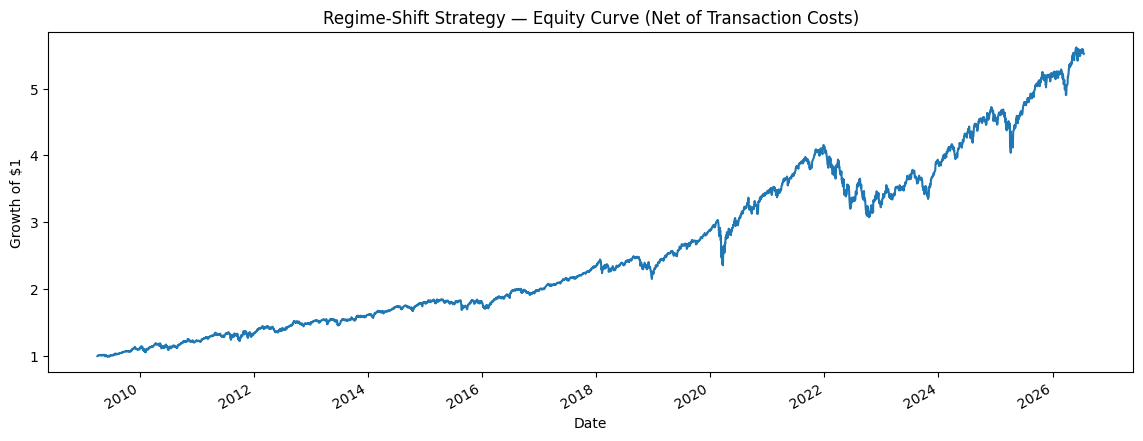

In [112]:
equity_curve = (1 + portfolio_net_return).cumprod()

import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
equity_curve.plot(title='Regime-Shift Strategy — Equity Curve (Net of Transaction Costs)')
plt.ylabel('Growth of $1')
plt.show()

In [113]:
weights_6040 = pd.Series({'SPY_ret': 0.6, 'TLT_ret': 0.4, 'IEF_ret': 0.0, 'GLD_ret': 0.0, 'HYG_ret': 0.0})

portfolio_6040_return = (dataset[return_cols] * weights_6040).sum(axis=1)
portfolio_6040_return = portfolio_6040_return.loc[daily_weights.index]  # align to same date range

equity_6040 = (1 + portfolio_6040_return).cumprod()

weights_equal = pd.Series({col: 0.2 for col in return_cols})


portfolio_equal_return = (dataset[return_cols] * weights_equal).sum(axis=1)
portfolio_equal_return = portfolio_equal_return.loc[daily_weights.index]

equity_equal = (1 + portfolio_equal_return).cumprod()

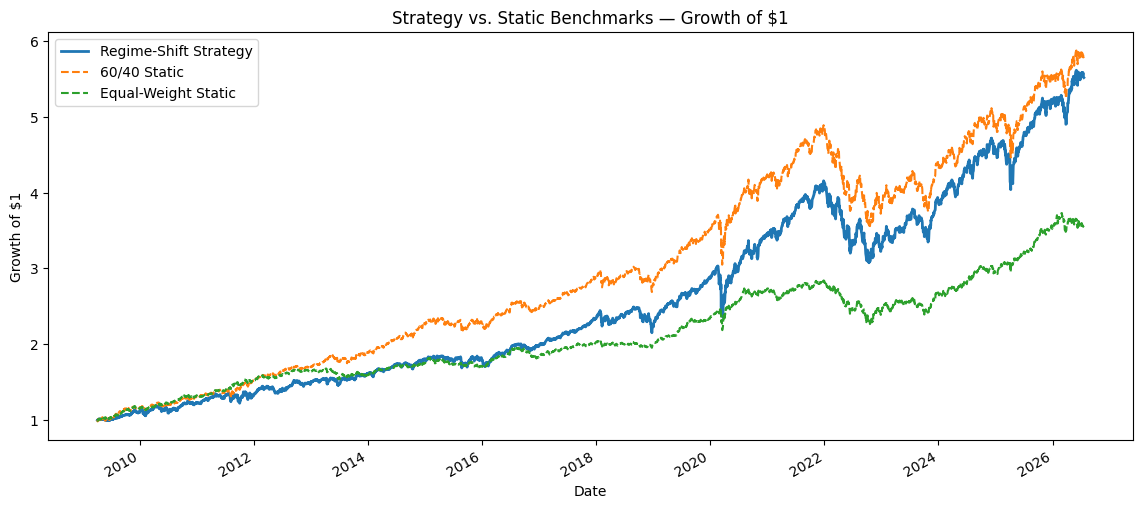

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
equity_curve.plot(label='Regime-Shift Strategy', linewidth=2)
equity_6040.plot(label='60/40 Static', linestyle='--')
equity_equal.plot(label='Equal-Weight Static', linestyle='--')
plt.legend()
plt.title('Strategy vs. Static Benchmarks — Growth of $1')
plt.ylabel('Growth of $1')
plt.show()

In [128]:


RISK_FREE_RATE = 0.03  # keep consistent with the Sharpe calc used earlier in the notebook

def annualized_return(returns):
    return returns.mean() * 252

def annualized_vol(returns):
    return returns.std() * np.sqrt(252)

def sharpe_ratio(returns, rf=RISK_FREE_RATE):
    ann_ret = annualized_return(returns)
    ann_vol = annualized_vol(returns)
    return (ann_ret - rf) / ann_vol if ann_vol != 0 else np.nan

def sortino_ratio(returns, rf=RISK_FREE_RATE):
    """Downside deviation uses only negative daily returns, annualized the same way as vol."""
    downside = returns[returns < 0]
    downside_dev = downside.std() * np.sqrt(252)
    ann_ret = annualized_return(returns)
    if downside_dev == 0 or np.isnan(downside_dev):
        return np.nan
    return (ann_ret - rf) / downside_dev

def drawdown_series(equity_curve):
    running_max = equity_curve.cummax()
    return equity_curve / running_max - 1.0

def max_drawdown(equity_curve):
    dd = drawdown_series(equity_curve)
    return dd.min(), dd

def calmar_ratio(returns, equity_curve, rf=0.0):
    """Calmar = annualized return / |max drawdown|. Uses rf=0 by convention (Calmar is a
    return-to-pain measure, not typically excess-of-risk-free)."""
    ann_ret = annualized_return(returns)
    mdd, _ = max_drawdown(equity_curve)
    return (ann_ret - rf) / abs(mdd) if mdd != 0 else np.nan


In [129]:
# --- Align all three return streams to the same date range and build equity curves ---

strategy_returns = portfolio_net_return.loc[daily_weights.index]
bench_6040_returns= portfolio_6040_return.loc[daily_weights.index]
bench_equal_returns = portfolio_equal_return.loc[daily_weights.index]

series = {
    'Regime-Shift Strategy': strategy_returns,
    '60/40 Static': bench_6040_returns,
    'Equal-Weight Static': bench_equal_returns,
}

equity_curves = {name: (1 + r).cumprod() for name, r in series.items()}


In [130]:
# --- Turnover ---
# Strategy: already computed per-rebalance (walk_forward_df['turnover']), 0.5 * L1 weight change.
# Benchmarks: both are static, never-rebalanced weight paths in this notebook (weights are applied
# once and let drift with returns -- no periodic rebalancing trades), so their turnover is 0 by
# construction here. If you later add periodic rebalancing to the benchmarks, recompute their
# turnover the same way (0.5 * sum(|weight_t - weight_{t-1}|)) before comparing.

strategy_turnover_per_rebalance = walk_forward_df['turnover']
strategy_avg_weekly_turnover = strategy_turnover_per_rebalance.mean()
strategy_annualized_turnover = strategy_avg_weekly_turnover * 52  # ~52 rebalances/year (weekly)

turnover_summary = {
    'Regime-Shift Strategy': strategy_annualized_turnover,
    '60/40 Static': 0.0,
    'Equal-Weight Static': 0.0,
}

print(f"Strategy avg weekly turnover: {strategy_avg_weekly_turnover:.4f}")
print(f"Strategy annualized turnover: {strategy_annualized_turnover:.2%}")


Strategy avg weekly turnover: 0.0180
Strategy annualized turnover: 93.82%


In [131]:
# --- Build the tear sheet table ---

rows = []
for name, r in series.items():
    eq = equity_curves[name]
    mdd, _ = max_drawdown(eq)
    rows.append({
        'Strategy': name,
        'Annualized Return': annualized_return(r),
        'Annualized Vol': annualized_vol(r),
        'Sharpe Ratio': sharpe_ratio(r),
        'Sortino Ratio': sortino_ratio(r),
        'Max Drawdown': mdd,
        'Calmar Ratio': calmar_ratio(r, eq),
        'Annualized Turnover': turnover_summary[name],
    })

tear_sheet = pd.DataFrame(rows).set_index('Strategy')

tear_sheet_display = tear_sheet.copy()
for col in ['Annualized Return', 'Annualized Vol', 'Max Drawdown', 'Annualized Turnover']:
    tear_sheet_display[col] = tear_sheet_display[col].apply(lambda x: f"{x:.2%}")
for col in ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']:
    tear_sheet_display[col] = tear_sheet_display[col].apply(lambda x: f"{x:.2f}")

tear_sheet_display


,Annualized Return,Annualized Vol,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Annualized Turnover
Strategy,,,,,,,
Regime-Shift Strategy,10.64%,12.15%,0.63,0.80,-26.03%,0.41,93.82%
60/40 Static,10.70%,10.35%,0.74,0.97,-27.24%,0.39,0.00%
Equal-Weight Static,7.60%,7.27%,0.63,0.86,-20.23%,0.38,0.00%


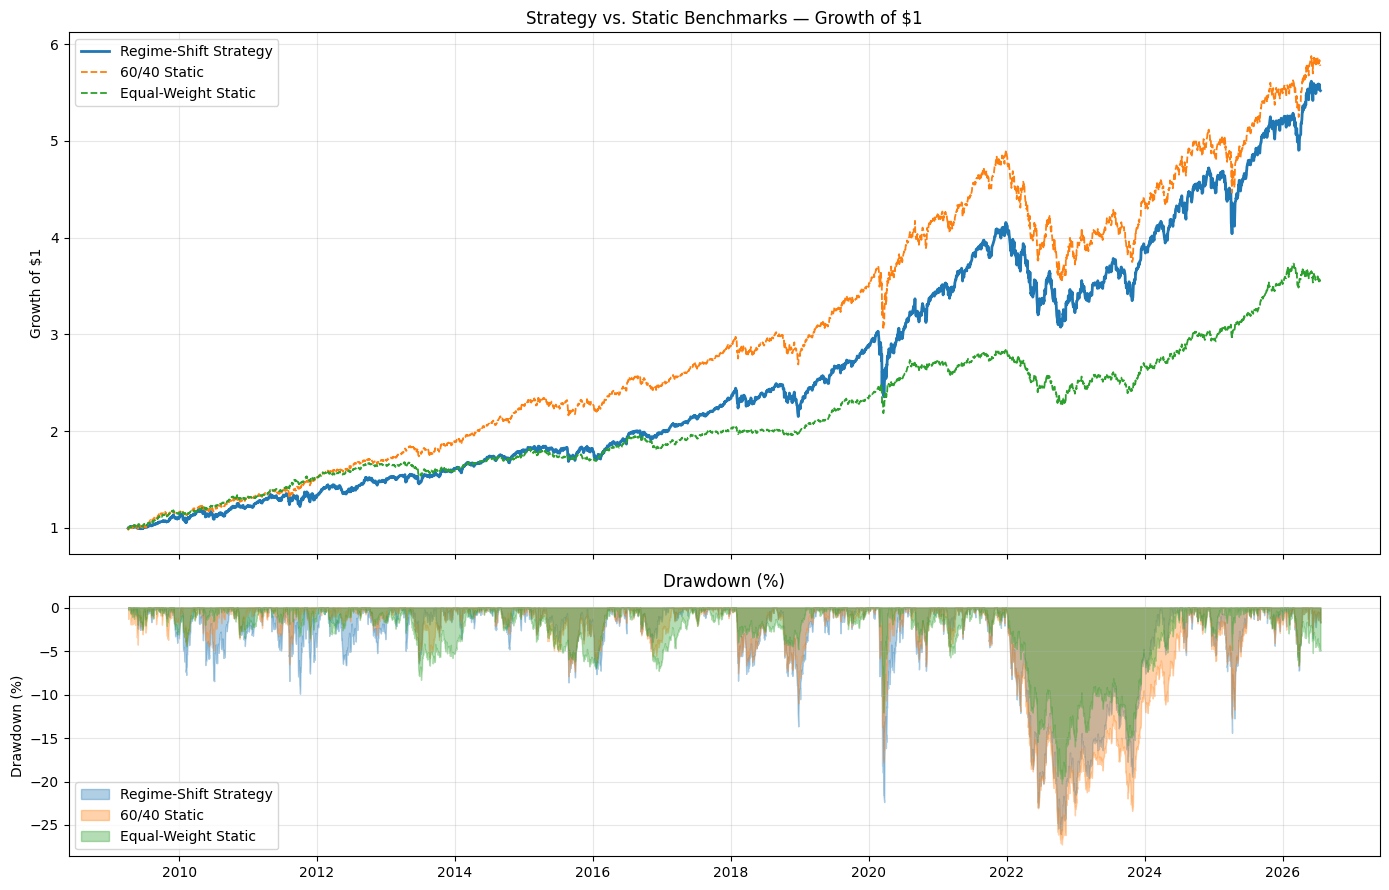

In [132]:
# --- Visual tear sheet: equity curves + drawdowns ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

colors = {
    'Regime-Shift Strategy': 'tab:blue',
    '60/40 Static': 'tab:orange',
    'Equal-Weight Static': 'tab:green',
}

for name, eq in equity_curves.items():
    axes[0].plot(eq.index, eq.values, label=name, color=colors[name],
                 linewidth=2 if name == 'Regime-Shift Strategy' else 1.3,
                 linestyle='-' if name == 'Regime-Shift Strategy' else '--')
axes[0].set_title('Strategy vs. Static Benchmarks — Growth of $1')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, eq in equity_curves.items():
    dd = drawdown_series(eq)
    axes[1].fill_between(dd.index, dd.values * 100, 0, color=colors[name], alpha=0.35, label=name)
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


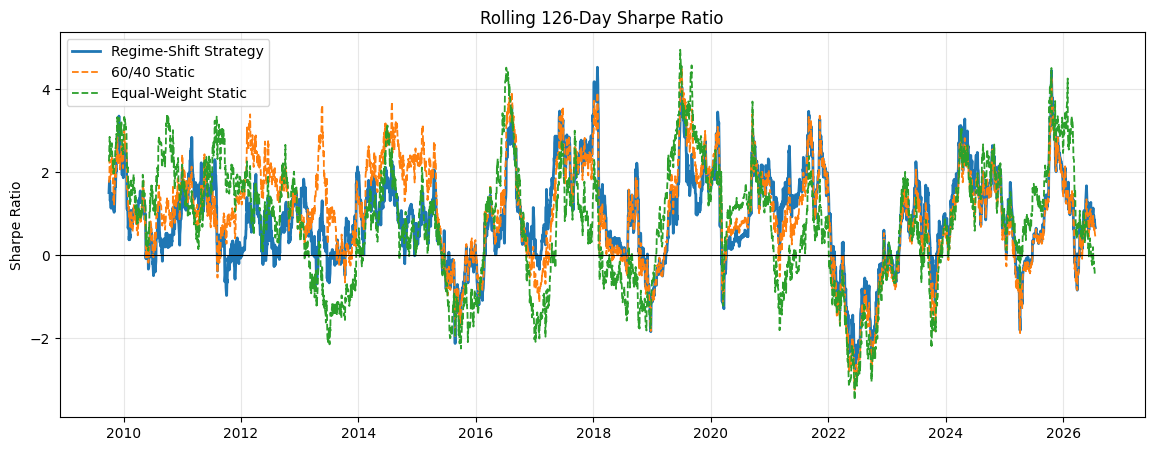

In [133]:
# --- Rolling 6-month (126 trading day) Sharpe, for a sense of regime-to-regime stability ---

ROLL_WINDOW = 126

fig, ax = plt.subplots(figsize=(14, 5))
for name, r in series.items():
    roll_ret = r.rolling(ROLL_WINDOW).mean() * 252
    roll_vol = r.rolling(ROLL_WINDOW).std() * np.sqrt(252)
    roll_sharpe = (roll_ret - RISK_FREE_RATE) / roll_vol
    ax.plot(roll_sharpe.index, roll_sharpe.values, label=name, color=colors[name],
            linewidth=2 if name == 'Regime-Shift Strategy' else 1.3,
            linestyle='-' if name == 'Regime-Shift Strategy' else '--')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Rolling {ROLL_WINDOW}-Day Sharpe Ratio')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(alpha=0.3)
plt.show()
